In [1]:
import torch
import pandas as pd
import json
from tqdm import tqdm
from config import INDEX_UNTIL, LAM_VALUES, REAL_DIR, TSR_DIR, PT_TSR_DIR, PROMPTS_FILE, MODEL_CACHE, SEED, TSR_SIGMA, SWAP_ALGORITHM, N_INF_STEPS, GUIDANCE_SCALE
import gc
from fid import (
	build_prompt_map, build_clip_model, build_feat_model,
	compute_real_stats, compute_fid_score, compute_clip, sanity_check
)
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
INDEX_UNTIL = 5

replica_exchanges = [True, False]

LAM_VALUES = [0.95, 0.9, 0.98]
LAM_FULL = LAM_VALUES + [1.0 + (1.0-l) for l in LAM_VALUES]

TSR_DIR     = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/tsr_test_new")
PT_TSR_DIR  = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/pt_test_new")

SWAP_ALGORITHM = {
	"n_replicas": 4,
	"p_ratio": "p",
	"even_indices": [2,  8, 12,  16],   # t ≈ 870, 763, 648, 536
	"odd_indices":  [4,  10, 14,  18],
	"debug": True,
}

# ── Load prompts once ─────────────────────────────────────────────────────────
TARGET_INDICES = ["00089", "00352", "00562", "00275", "00036",
                  "00006", "00505", "00482", "00356", "00182",
                  "00305", "00538", "00169", "00551", "00170"]

df = pd.read_csv(PROMPTS_FILE, dtype={"original_idx": str})
mask = df["original_idx"].isin(TARGET_INDICES)
subset_df = df[mask].reset_index(drop=True)
prompts = subset_df["text"].tolist()[:INDEX_UNTIL]
print(f"Loaded {len(prompts)} prompts")

Loaded 5 prompts


In [3]:
gc.collect()
torch.cuda.empty_cache()

In [4]:
from diffusers import StableDiffusion3Pipeline

# ── Load model once ───────────────────────────────────────────────────────────
pipe = StableDiffusion3Pipeline.from_pretrained(
	"stabilityai/stable-diffusion-3-medium-diffusers",
	torch_dtype=torch.float16,
	cache_dir=MODEL_CACHE,
)
pipe = pipe.to("cuda")
pipe.set_progress_bar_config(disable=True)

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

In [5]:
for replica_exchange in replica_exchanges:

	if replica_exchange:
		BASE_OUTPUT_DIR = PT_TSR_DIR
		LAM_ALL = LAM_VALUES
	else:
		BASE_OUTPUT_DIR = TSR_DIR
		LAM_ALL = LAM_FULL

	# ── Sweep ─────────────────────────────────────────────────────────────────────
	for tsr_lam in LAM_ALL:
		k_str = f"lam{tsr_lam:.3f}".replace(".", "p")   # e.g. "k0p950" — safe for filenames
		output_dir = BASE_OUTPUT_DIR / k_str
		checkpoint_file = output_dir / "completed.json"
		output_dir.mkdir(parents=True, exist_ok=True)

		if replica_exchange:
			k_str_flipped = f"lam{2.0-tsr_lam:.3f}".replace(".", "p")   # e.g. "k0p950" — safe for filenames
			output_dir_flipped = BASE_OUTPUT_DIR / k_str_flipped
			checkpoint_file_flipped = output_dir_flipped / "completed.json"
			output_dir_flipped.mkdir(parents=True, exist_ok=True)

		existing = list(output_dir.glob("*.png"))
		completed = set(range(len(existing)))
		if existing:
			print(f"\n[k={tsr_lam}] Resuming — {len(completed)}/{len(prompts)} done")
		else:
			completed = set()
			print(f"\n[k={tsr_lam}] Starting fresh")

		for idx, prompt in enumerate(tqdm(prompts, desc=f"k={tsr_lam}")):
			if idx in completed:
				continue

			generator = torch.Generator(device="cuda").manual_seed(SEED + idx)

			images = pipe(
				prompt,
				negative_prompt="",
				num_inference_steps=N_INF_STEPS,
				guidance_scale=GUIDANCE_SCALE,
				tsr_lam=tsr_lam,
				tsr_sigma=TSR_SIGMA,
				replica_exchange=replica_exchange,
				swap_algorithm=SWAP_ALGORITHM,
				generator=generator,
			).images

			out_path = output_dir / f"{df.iloc[idx]['original_idx']}.png"

			if replica_exchange:
				images[1].save(out_path, icc_profile=None)
				out_path = output_dir_flipped / f"{df.iloc[idx]['original_idx']}.png"
				images[2].save(out_path, icc_profile=None)
			else:
				images[-1].save(out_path, icc_profile=None)
			
			del images
			torch.cuda.empty_cache()

			completed.add(idx)
			if idx % 50 == 0:
				checkpoint_file.write_text(json.dumps(list(completed)))


		checkpoint_file.write_text(json.dumps(list(completed)))
		print(f"[k={tsr_lam}] Done — {len(completed)} images saved to {output_dir}")

	print("\n All k values complete.")


[k=0.95] Resuming — 5/5 done


k=0.95: 100%|██████████| 5/5 [00:00<00:00, 52298.05it/s]


[k=0.95] Done — 5 images saved to /n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/pt_test_new/lam0p950

[k=0.9] Resuming — 5/5 done


k=0.9: 100%|██████████| 5/5 [00:00<00:00, 101311.69it/s]


[k=0.9] Done — 5 images saved to /n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/pt_test_new/lam0p900

[k=0.98] Starting fresh


...

 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02


k=1.02:  80%|████████  | 4/5 [00:42<00:10, 10.67s/it]

 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02
 We tsr by 1.02


k=1.02: 100%|██████████| 5/5 [00:54<00:00, 10.84s/it]

[k=1.02] Done — 5 images saved to /n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/tsr_test_new/lam1p020

 All k values complete.


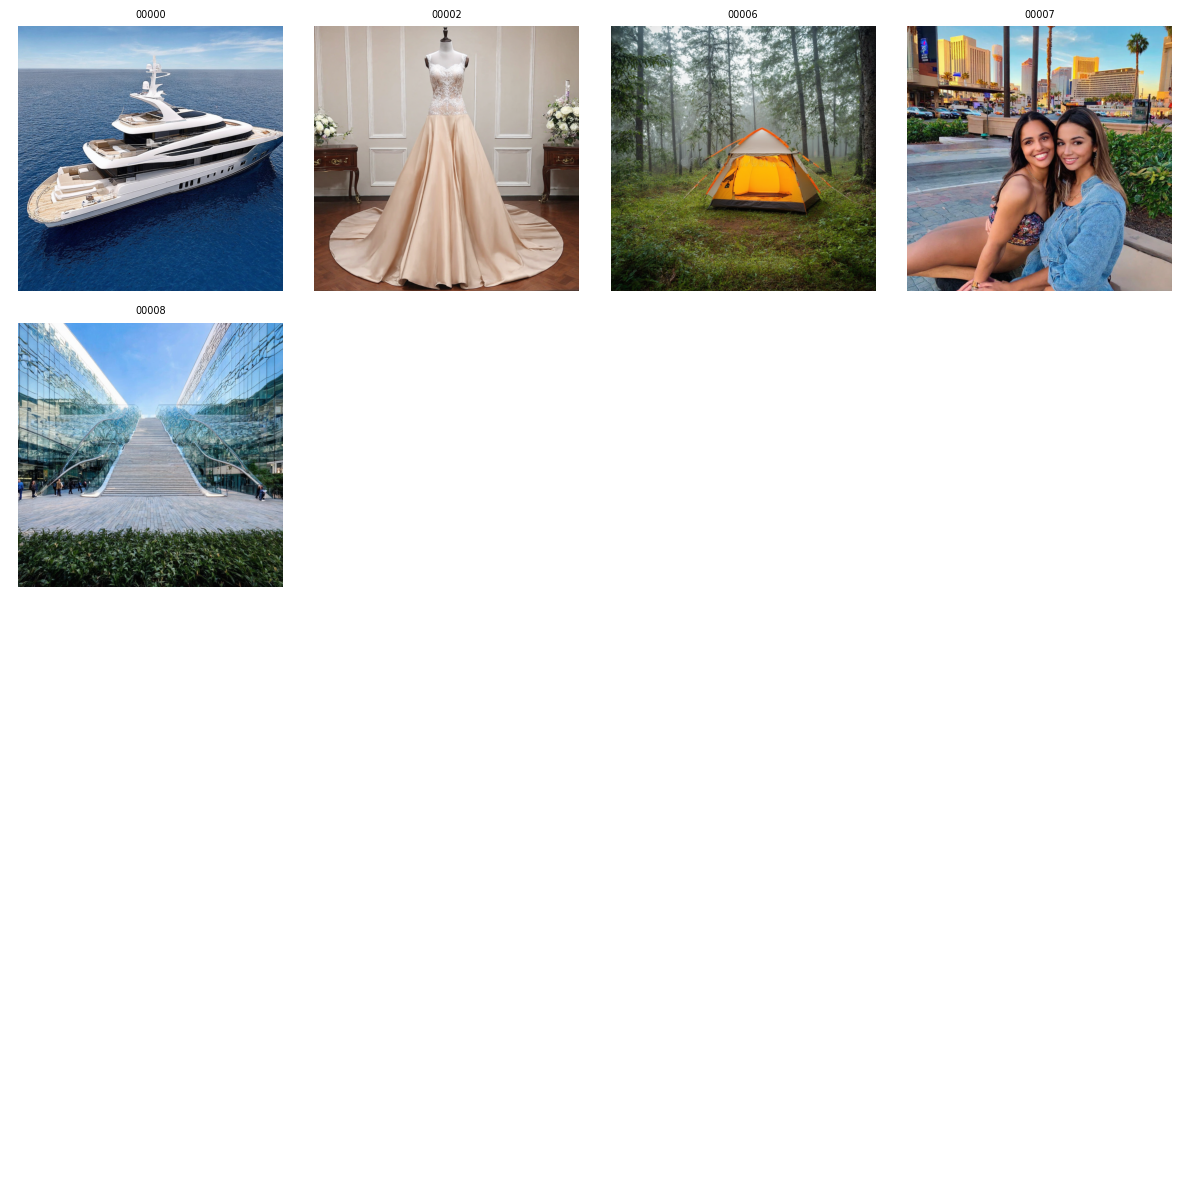

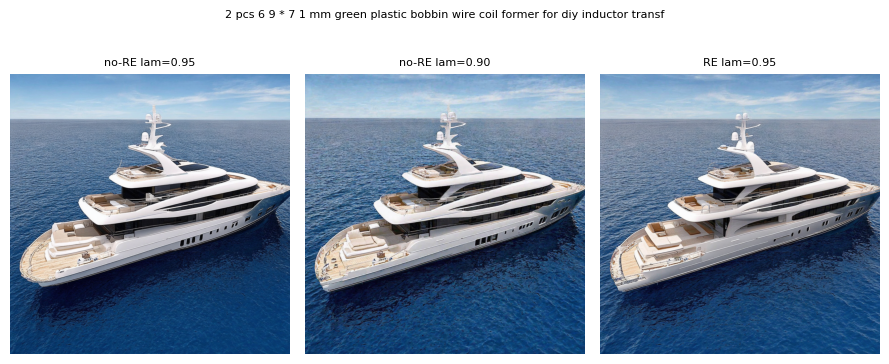

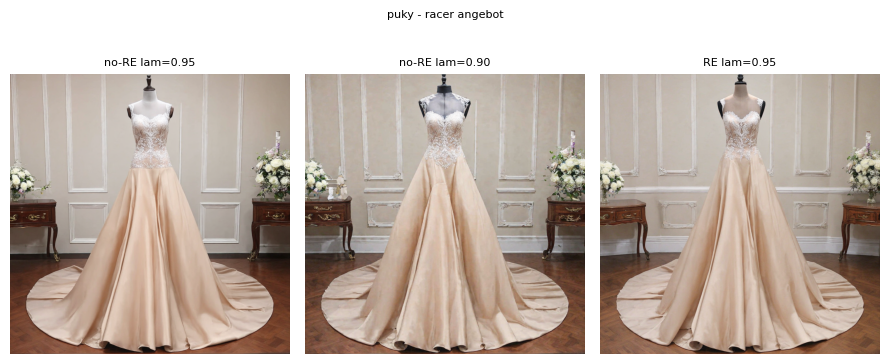

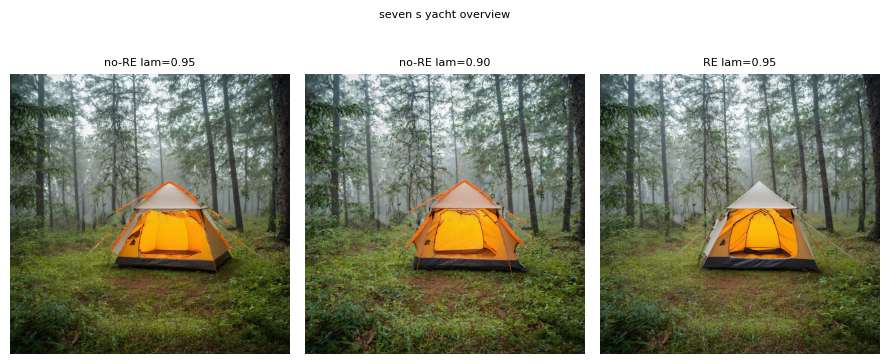

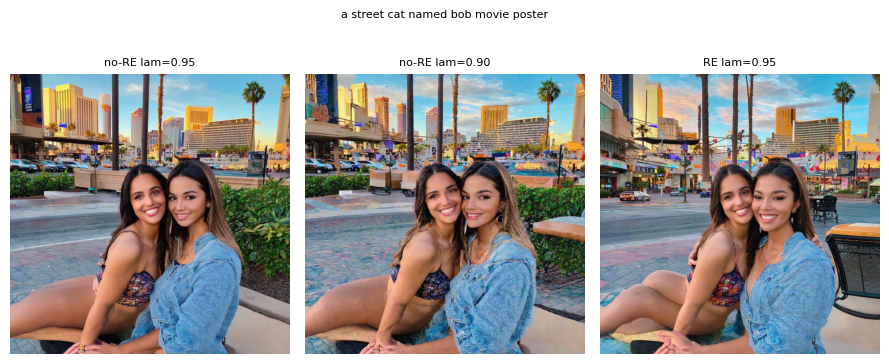

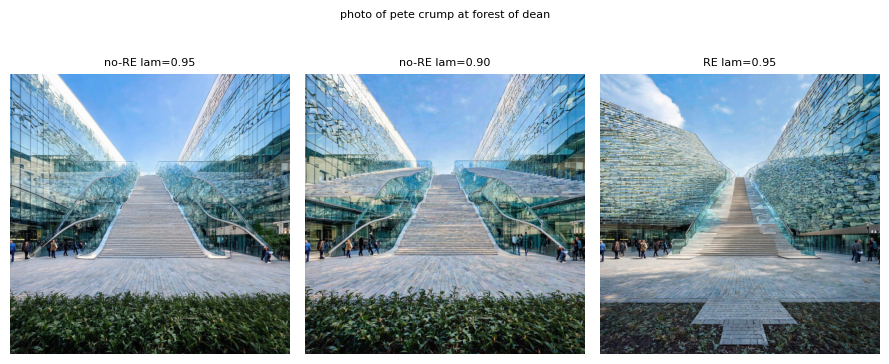

In [6]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

def show_samples(folder, n=16, cols=4):
    files = sorted(Path(folder).glob("*.png"))[:n]
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    for ax, f in zip(axes.flatten(), files):
        ax.imshow(Image.open(f))
        ax.set_title(f.stem, fontsize=7)
        ax.axis("off")
    # hide unused axes
    for ax in axes.flatten()[len(files):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(TSR_DIR / "lam0p950")

def compare_methods(dirs, labels, idx, df):
    orig_idx = df.iloc[idx]['original_idx']
    prompt = df.iloc[idx]['text']
    
    fig, axes = plt.subplots(1, len(dirs), figsize=(len(dirs)*3, 4))
    fig.suptitle(prompt[:80], fontsize=8)
    for ax, d, label in zip(axes, dirs, labels):
        path = Path(d) / f"{orig_idx}.png"
        if path.exists():
            ax.imshow(Image.open(path))
        ax.set_title(label, fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Same image, different lam values
for i in range(5):
    compare_methods(
        [TSR_DIR / "lam0p950", TSR_DIR / "lam0p900", PT_TSR_DIR / "lam0p950"],
        ["no-RE lam=0.95", "no-RE lam=0.90", "RE lam=0.95"],
        idx=i, df=df
    )

In [7]:
device = "cuda"

# ── Initialize models once ────────────────────────────────────────────────────
prompt_map                 = build_prompt_map()
clip_model, clip_processor = build_clip_model(device)
feat_model                 = build_feat_model(device)
mu_real, sigma_real        = compute_real_stats(feat_model, device, n=INDEX_UNTIL)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/n/home00/zoewu/.local/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Computing real image features...


100%|██████████| 1/1 [00:01<00:00,  1.24s/it]

Real features computed from 5 images.



In [8]:
# At the top of your notebook, after imports
from PIL import Image
Image.MAX_IMAGE_PIXELS = None
import warnings
warnings.filterwarnings("ignore", category=Image.DecompressionBombWarning)

# Patch PIL to strip ICC profiles on load
_orig_open = Image.open
def _open_no_icc(fp, *args, **kwargs):
	img = _orig_open(fp, *args, **kwargs)
	if "icc_profile" in img.info:
		img = img.convert("RGB")
	return img
Image.open = _open_no_icc

In [ ]:
# ── Compute ───────────────────────────────────────────────────────────────────
tsr_results = {alg: {} for alg in replica_exchanges}
TSR_DIRS = []

for alg in replica_exchanges:
	if alg == False:
		TSR_DIRS.append(TSR_DIR)
	elif alg == True:
		TSR_DIRS.append(PT_TSR_DIR)

for tsr_lam in LAM_FULL :
	lam_str = f"lam{tsr_lam:.3f}".replace(".", "p")
	print(f"\n── {lam_str} ──")

	for alg_idx, tsr_samples_dir in enumerate(TSR_DIRS):
		alg = replica_exchanges[alg_idx]
		samples_dir = (TSR_DIR if tsr_lam == 1.0 else tsr_samples_dir) / lam_str

		png_files = sorted(samples_dir.glob("*.png"))[:INDEX_UNTIL]
		if not png_files:
			print(f"[{alg}]  lam={tsr_lam:.3f}  SKIPPED (no PNGs in {samples_dir})")
			continue

		fid_val  = compute_fid_score(samples_dir, feat_model, mu_real, sigma_real, device, n=INDEX_UNTIL)
		clip_val = compute_clip(samples_dir, tsr_lam, prompt_map, clip_model, clip_processor, device, index_until=INDEX_UNTIL)
		tsr_results[alg][tsr_lam] = (fid_val, clip_val)
		print(f"[{alg}]  lam={tsr_lam:.3f}  FID={fid_val:.4f}  CLIP={clip_val:.4f}")

/n/home00/zoewu/.local/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



── lam0p950 ──


CLIP lam=0.95: 100%|██████████| 5/5 [00:00<00:00, 10.05it/s]


[True]  lam=0.950  FID=338.5738  CLIP=14.0569


CLIP lam=0.95: 100%|██████████| 5/5 [00:00<00:00, 20.60it/s]


...

CLIP lam=1.05: 100%|██████████| 5/5 [00:00<00:00, 17.29it/s]


[True]  lam=1.050  FID=299.7853  CLIP=13.7401


CLIP lam=1.05: 100%|██████████| 5/5 [00:00<00:00, 20.30it/s]


[False]  lam=1.050  FID=312.7421  CLIP=14.1858

── lam1p100 ──


100%|██████████| 1/1 [00:00<00:00,  1.29it/s]


In [ ]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for alg in replica_exchanges:
	tsr_lam_vals    = sorted(tsr_results[alg].keys(), reverse=True)
	tsr_clip_vals = [tsr_results[alg][lam][1] for lam in tsr_lam_vals]
	tsr_fid_vals  = [tsr_results[alg][lam][0] for lam in tsr_lam_vals]

	ax.plot(tsr_clip_vals, tsr_fid_vals, marker="o", linewidth=2, label=f"{alg}, CFG=7.5, σ=3.0")
	for lam in tsr_lam_vals:
		f, c = tsr_results[alg][lam]
		ax.annotate(f"lam={lam}", (c, f), textcoords="offset points", xytext=(6, 0), fontsize=8, color="goldenrod")

ax.set_xlabel("CLIP", fontsize=12)
ax.set_ylabel("FID", fontsize=12)
ax.set_title("FID vs CLIP comparison", fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fid_vs_clip.png", dpi=150)
plt.show()